# CBIS-DDSM Dataset

This notebook describes my exploratory dataset analysis of the CBIS-DDSM dataset (Lee et al).

Firstly, we import some libraries used throughout the notebook.

## Imports

In [1]:
from pathlib import Path

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
from PIL import Image
from pydantic import BaseModel

In [2]:
DATASET_ROOT = Path("../datasets/CBIS-DDSM")
IMG_ROOT = DATASET_ROOT / "CBIS-DDSM"

## Dataset Overview

The dataset was downloaded from from https://www.cancerimagingarchive.net/collection/cbis-ddsm.

It is a 164GB compressed dataset which uncompresses to around 180GB.

The CSV provided by the original authors actually has a number of issues. In the image dataset, the DICOM images are named as `1-1.dcm` or `1-2.dcm`, but in the description files (CSV), they are named as `000000.dcm` or `000001.dcm`. Confusingly, the `000000.dcm` and `000001.dcm` are not consistently mapped to `1-1.dcm` or `1-2.dcm` files.

Andrés Sarmiento wrote some scripts that fixes these issues, actually resorting to integorgating the mask files to determine if they're crops or masks. The repo is here: https://gitlab.com/ACSG-64/cbis-ddsm-description-correction-and-verification-tool/-/tree/main?ref_type=heads

He provides a corrected version of the dataset here, which I'm using in this notebook (in folder `fixed-csv`), as a substitute for the official `.csv` data: https://huggingface.co/datasets/ACSG-64/CBIS-DDSM-description-corrected

In [3]:
!cd {DATASET_ROOT} && du -sh *

512K	calc_case_description_test_set.csv
1.0M	calc_case_description_train_set.csv
180G	CBIS-DDSM
5.5M	fixed-csv
512K	mass_case_description_test_set.csv
1.0M	mass_case_description_train_set.csv
3.0M	metadata.csv


## Metadata File Review

There is 2 files provided for each split, representing either calcification or mass abnormalities found in the breast.

- `calc_case_description_${train|test}_set.csv`
- `mass_case_description_${train|test}_set.csv`

Here we load each file, then concat together to give us one dataset file per split.

In [4]:
train_mass_df = pd.read_csv(DATASET_ROOT / "fixed-csv" / "mass_case_description_train_set.csv")
train_calc_df = pd.read_csv(DATASET_ROOT / "fixed-csv" / "calc_case_description_train_set.csv")
train_df = pd.concat([train_mass_df, train_calc_df])
train_mass_df = train_calc_df = None
train_df.head(1)

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast density,calc type,calc distribution
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN


In [6]:
test_mass_df = pd.read_csv(DATASET_ROOT / "fixed-csv" /  "mass_case_description_test_set.csv")
test_calc_df = pd.read_csv(DATASET_ROOT / "fixed-csv" /  "calc_case_description_test_set.csv")
test_df = pd.concat([test_mass_df, test_calc_df])
test_mass_df = test_mass_df = None
test_df.head(1)

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast density,calc type,calc distribution
0,P_00016,4.0,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,NaN,NaN,NaN


In [7]:
all_df = pd.concat([train_df, test_df])

In [8]:
metadata_df = pd.read_csv(DATASET_ROOT / "metadata.csv")
metadata_df.head(1)

,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,Modality,SOP Class Name,SOP Class UID,Number of Images,File Size,File Location,Download Timestamp
0,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Calc-Test_P_00038_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.161465562211359959230...,NaN,08-29-2017,ROI mask images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,2,14.06 MB,./CBIS-DDSM/Calc-Test_P_00038_LEFT_CC_1/08-29-...,2025-11-25T05:30:27.736


The paper claims that there's 891 mass cases, although the actual dataset appears to have 892 mass abnormalities.

In [9]:
len(all_df[all_df["abnormality type"] == "mass"].patient_id.unique())

892

The paper also describes 753 calcification abnormalities, which matches what we see in the paper.

In [10]:
len(all_df[all_df["abnormality type"] == "calcification"].patient_id.unique())

753

We have a total of 1566 patients in the dataset:

In [11]:
images_per_patient = all_df.groupby("patient_id").size()
print(f"Total patients: {len(images_per_patient)}")

Total patients: 1566


And mostly we have 2 images per patient (the MLO and CC), although some have many more.

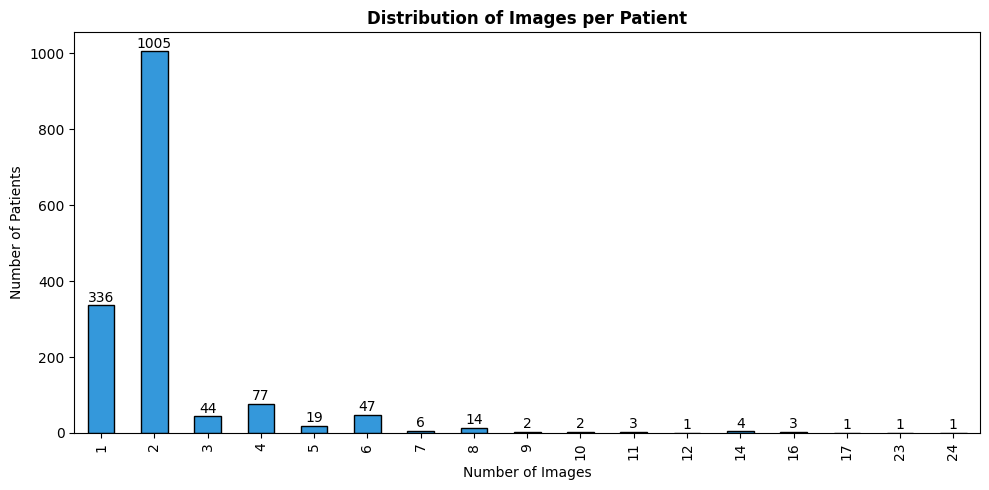

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
images_per_patient.value_counts().sort_index().plot(kind='bar', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Distribution of Images per Patient', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Images')
ax.set_ylabel('Number of Patients')
for i, v in enumerate(images_per_patient.value_counts().sort_index().values):
    ax.text(i, v + 2, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

Let's have a closer look at one patient id to start with. Later we'll try to understand stastics for all patient ids.

In [13]:
patient_5 = all_df[all_df.patient_id == "P_00065"]

In [14]:
patient_5

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast density,calc type,calc distribution
47,P_00065,2.0,LEFT,CC,1,mass,OVAL,OBSCURED,0,BENIGN,5,Mass-Training_P_00065_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00065_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00065_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN
48,P_00065,2.0,LEFT,MLO,1,mass,OVAL,OBSCURED,0,BENIGN,5,Mass-Training_P_00065_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00065_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00065_LEFT_MLO_1/1.3.6.1.4.1.9...,NaN,NaN,NaN


## Image Extraction

Each row, which represents a view of the patient's breast contains references to 3 dicom files:

- image file path
- ROI mask file path
- cropped image file path

In [15]:
patient_5_row = patient_5.iloc[0]
dict(patient_5_row[["image file path", "cropped image file path", "ROI mask file path"]])

{'image file path': 'Mass-Training_P_00065_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.382401081413353949132934135242319307979/1.3.6.1.4.1.9590.100.1.2.426908919112508199513948266470990243457/1-1.dcm',
 'cropped image file path': 'Mass-Training_P_00065_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.190063993111994485334508742762091065664/1.3.6.1.4.1.9590.100.1.2.213055477011614464512849059040123864462/1-2.dcm',
 'ROI mask file path': 'Mass-Training_P_00065_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.190063993111994485334508742762091065664/1.3.6.1.4.1.9590.100.1.2.213055477011614464512849059040123864462/1-1.dcm'}

The filename can't be loaded directly, but we can fetch the subject id, study uid and series uid from the file name.

In [16]:
class DCMData(BaseModel):
    subject_id: str
    study_uid: str
    series_uid: str
    dcm_file: str
    

def get_file_data_from_dcm(dcm_path: Path):
    data = str(dcm_path).strip().split("/")
    dcm_og = data[-1].strip().split(".")[0]
    return DCMData(subject_id=data[0], study_uid=data[1], series_uid=data[2], dcm_file=dcm_og)

In [17]:
patient_5_row["cropped image file path"]

'Mass-Training_P_00065_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.190063993111994485334508742762091065664/1.3.6.1.4.1.9590.100.1.2.213055477011614464512849059040123864462/1-2.dcm'

In [18]:
patient_5_row["ROI mask file path"]

'Mass-Training_P_00065_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.190063993111994485334508742762091065664/1.3.6.1.4.1.9590.100.1.2.213055477011614464512849059040123864462/1-1.dcm'

In [19]:
patient_5_row["image file path"]

'Mass-Training_P_00065_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.382401081413353949132934135242319307979/1.3.6.1.4.1.9590.100.1.2.426908919112508199513948266470990243457/1-1.dcm'

In [20]:
patient_5_cropped_file = get_file_data_from_dcm(patient_5_row["cropped image file path"])
patient_5_roi_mask_file = get_file_data_from_dcm(patient_5_row["ROI mask file path"])
patient_5_image_file = get_file_data_from_dcm(patient_5_row["image file path"])
patient_5_cropped_file, patient_5_roi_mask_file, patient_5_image_file

(DCMData(subject_id='Mass-Training_P_00065_LEFT_CC_1', study_uid='1.3.6.1.4.1.9590.100.1.2.190063993111994485334508742762091065664', series_uid='1.3.6.1.4.1.9590.100.1.2.213055477011614464512849059040123864462', dcm_file='1-2'),
 DCMData(subject_id='Mass-Training_P_00065_LEFT_CC_1', study_uid='1.3.6.1.4.1.9590.100.1.2.190063993111994485334508742762091065664', series_uid='1.3.6.1.4.1.9590.100.1.2.213055477011614464512849059040123864462', dcm_file='1-1'),
 DCMData(subject_id='Mass-Training_P_00065_LEFT_CC', study_uid='1.3.6.1.4.1.9590.100.1.2.382401081413353949132934135242319307979', series_uid='1.3.6.1.4.1.9590.100.1.2.426908919112508199513948266470990243457', dcm_file='1-1'))

Now we can query the metadata to find the actual file locations.

In [21]:
def get_filepath_from_dcm_data(dcm_data: DCMData):
    cropped_meta = metadata_df[
        (metadata_df["Subject ID"] == dcm_data.subject_id) &
        (metadata_df["Series UID"] == dcm_data.series_uid) &
        (metadata_df["Study UID"] == dcm_data.study_uid)
    ].iloc[0]
    file_location = cropped_meta["File Location"]
    return DATASET_ROOT / Path(file_location) / (dcm_data.dcm_file + ".dcm")

meta_img_path = get_filepath_from_dcm_data(patient_5_image_file)
meta_cropped_path = get_filepath_from_dcm_data(patient_5_cropped_file)
meta_roi_mask_path = get_filepath_from_dcm_data(patient_5_roi_mask_file)

In [22]:
meta_img_path, meta_cropped_path, meta_roi_mask_path

(PosixPath('../datasets/CBIS-DDSM/CBIS-DDSM/Mass-Training_P_00065_LEFT_CC/07-20-2016-DDSM-NA-07979/1.000000-full mammogram images-43457/1-1.dcm'),
 PosixPath('../datasets/CBIS-DDSM/CBIS-DDSM/Mass-Training_P_00065_LEFT_CC_1/07-21-2016-DDSM-NA-65664/1.000000-ROI mask images-64462/1-2.dcm'),
 PosixPath('../datasets/CBIS-DDSM/CBIS-DDSM/Mass-Training_P_00065_LEFT_CC_1/07-21-2016-DDSM-NA-65664/1.000000-ROI mask images-64462/1-1.dcm'))

The raw image is in a directory as a stand-alone file:

In [23]:
def get_img_from_file_location(file_location: Path):
    files = list(file_location.glob("*.dcm"))
    return files[0]

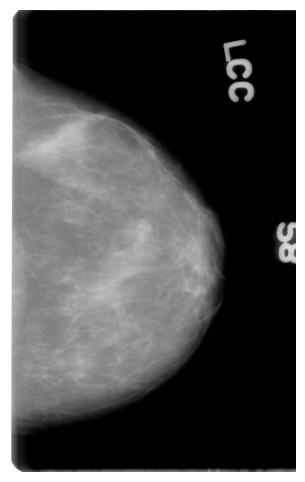

In [24]:
ds = pydicom.dcmread(meta_img_path)
img = ds.pixel_array

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [25]:
def show_img_grid(img_1, img_2, titles=None):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_1, cmap='gray')
    if titles:
        axes[0].set_title(titles[0])
    axes[0].axis('off')
    
    axes[1].imshow(img_2, cmap='gray')
    if titles:
        axes[1].set_title(titles[1])
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [26]:
def dicom_to_array(file):
    ds = pydicom.dcmread(file)
    return ds.pixel_array

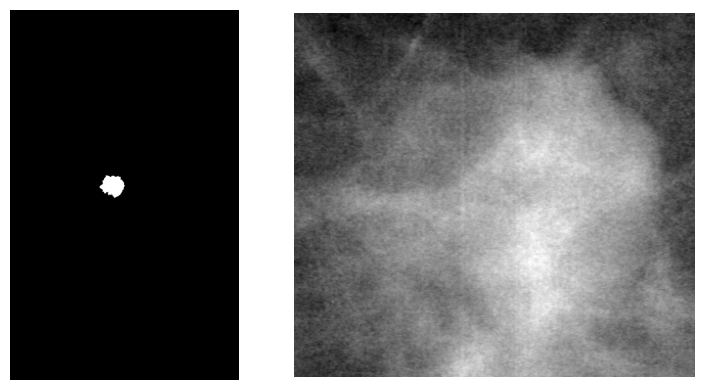

In [27]:
mask_img = dicom_to_array(meta_roi_mask_path)
crop_img = dicom_to_array(meta_cropped_path)

show_img_grid(mask_img, crop_img)

Finally to visualise the ROI over the image.

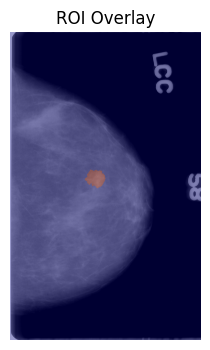

In [28]:
patient_np = np.array(img)
mask_np = np.array(mask_img)

plt.figure(figsize=(4,4))
plt.imshow(patient_np, cmap='gray')

# overlay mask with transparency
plt.imshow(mask_np, cmap='jet', alpha=0.4)

plt.axis("off")
plt.title("ROI Overlay")
plt.show()

To wrap all that into a single function:

In [29]:
def get_patient_imgs_from_row(row):
    dcm_data_img = get_file_data_from_dcm(row["image file path"])
    img_path = get_filepath_from_dcm_data(dcm_data_img)

    crop_file = get_filepath_from_dcm_data(get_file_data_from_dcm(row["cropped image file path"]))
    mask_file = get_filepath_from_dcm_data(get_file_data_from_dcm(row["ROI mask file path"]))

    return img_path, mask_file, crop_file

In [30]:
get_patient_imgs_from_row(patient_5.iloc[0])

(PosixPath('../datasets/CBIS-DDSM/CBIS-DDSM/Mass-Training_P_00065_LEFT_CC/07-20-2016-DDSM-NA-07979/1.000000-full mammogram images-43457/1-1.dcm'),
 PosixPath('../datasets/CBIS-DDSM/CBIS-DDSM/Mass-Training_P_00065_LEFT_CC_1/07-21-2016-DDSM-NA-65664/1.000000-ROI mask images-64462/1-1.dcm'),
 PosixPath('../datasets/CBIS-DDSM/CBIS-DDSM/Mass-Training_P_00065_LEFT_CC_1/07-21-2016-DDSM-NA-65664/1.000000-ROI mask images-64462/1-2.dcm'))

As mentioned, most patient are complete one-breast mammograms that have a CC view and an MLO view.

In [31]:
cc_path, *_ = get_patient_imgs_from_row(patient_5[patient_5["image view"] == "CC"].iloc[0])
mlo_path, *_ = get_patient_imgs_from_row(patient_5[patient_5["image view"] == "MLO"].iloc[0])

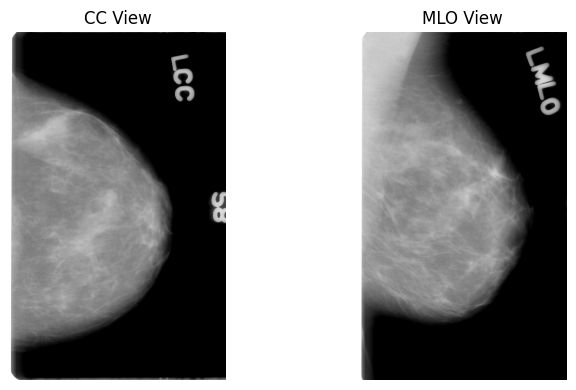

In [32]:
show_img_grid(dicom_to_array(cc_path), dicom_to_array(mlo_path), ["CC View", "MLO View"])

And another example:

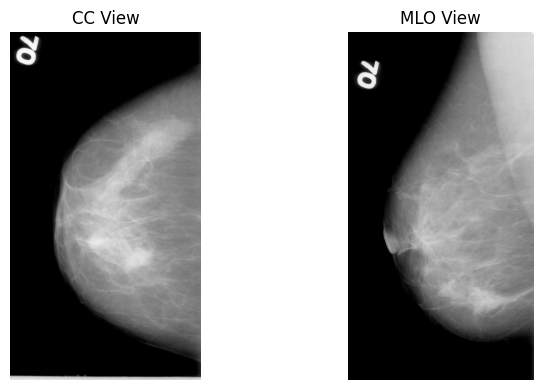

In [33]:
patient_02033 = all_df[all_df.patient_id == "P_02033"].reset_index(drop=True)
get_patient_imgs_from_row(patient_02033[patient_02033["image view"] == "CC"].iloc[0])

cc_path, *_ = get_patient_imgs_from_row(patient_02033[patient_02033["image view"] == "CC"].iloc[0])
mlo_path, *_ = get_patient_imgs_from_row(patient_02033[patient_02033["image view"] == "MLO"].iloc[0])

cc_img = dicom_to_array(cc_path)
show_img_grid(cc_img, dicom_to_array(mlo_path), ["CC View", "MLO View"])

## Manual Breast Extraction

Since we want to explore the possibility of utilising this model again Mammogram data that does not contain region-of-interest annotations, I want to explore an alternate method of breast extraction, which aims to remove blank space, and non-breast noise from the image using thresholding. Some of this work builds upon the knowledge that I gain from studying signal processing in CM3065 - Intelligent Signal Processing.

To attempt to crop some of the area around the breast, I'll utilise some classical object detection approaches.

I created some utility functions.

In [34]:
def show_img_grid(img_1, img_2):
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(img_1, cmap='gray')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].imshow(img_2, cmap='gray')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()

In [35]:
sample_img = cc_img

### Gaussian Blur

A 5×5 Gaussian blur smooths out high-frequency noise while preserving the overall structure. This prevents small noise pixels from creating spurious regions during thresholding.

Source: https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html

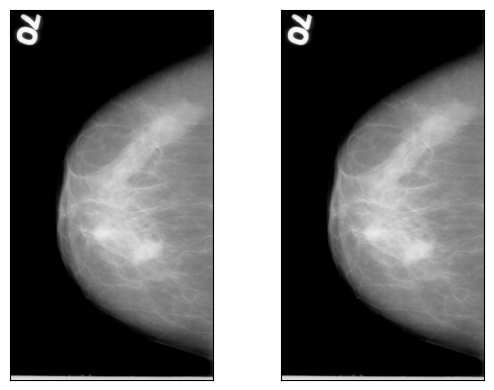

In [36]:
blurred_img = cv2.GaussianBlur(sample_img, (5, 5), 0)
show_img_grid(sample_img, blurred_img)

### Otsu's Thresholding

Otsu's method automatically determines the optimal threshold value by minimising intra-class variance (or equivalently, maximising inter-class variance) between foreground and background pixels. This is ideal for separating the breast tissue from the dark background without manual threshold tuning.

Source: https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

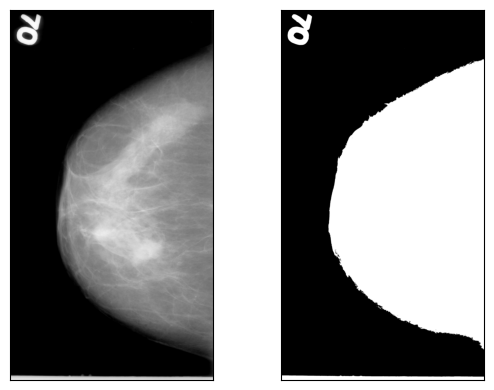

In [37]:
_, breast_mask = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
show_img_grid(blurred_img, breast_mask)

### Morphological Transformations

Morphological operations refine the binary mask by removing noise and filling gaps:

- **Opening** (erosion followed by dilation): Removes small bright spots/noise outside the breast region
- **Closing** (dilation followed by erosion): Fills small holes within the breast region

The 100×100 kernel size is chosen to handle the large scale of mammogram images (typically 3000-5000 pixels). Multiple iterations of closing ensure continuous breast boundaries.

In [38]:
def apply_morphological_transforms(
    thresh_frame, iterations: int = 2
):
    kernel = np.ones((100, 100), np.uint8)
    opened_mask = cv2.morphologyEx(thresh_frame, cv2.MORPH_OPEN, kernel)
    closed_mask = cv2.morphologyEx(opened_mask, cv2.MORPH_CLOSE, kernel, iterations=iterations)
    return closed_mask

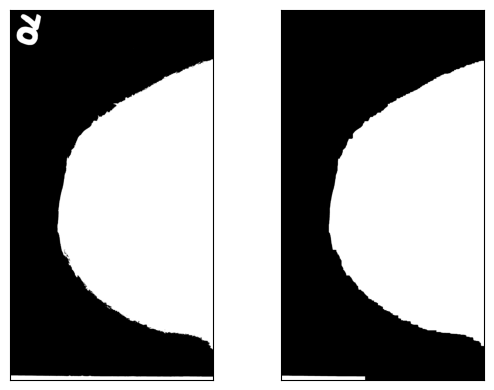

In [39]:
morph_img = apply_morphological_transforms(breast_mask)
show_img_grid(breast_mask, morph_img)

As we can see, it has removed the noisy label.

Next we can find countours, and use the max contour as the overall bounding box.

In [40]:
def get_contours_from_mask(mask):
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    return (x, y, w, h)

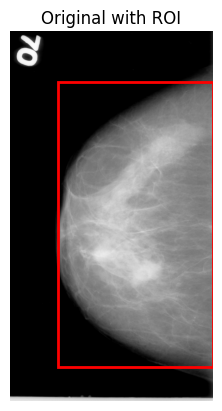

In [41]:
x, y, w, h = get_contours_from_mask(morph_img)

plt.imshow(sample_img, cmap='gray')
ax = plt.gca()

rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.title('Original with ROI')
plt.axis('off')
plt.show()

Very nice, near perfect bounding box around the breast area.

## Metadata EDA

Firstly, we'll take a look some of the provided metadata, to better understand the CBIS-DDSM dataset.

### Pathology Distribution

The most important label is `pathology`, which indicates whether the abnormality is benign or malignant.

We explore the distribution over each dataset.

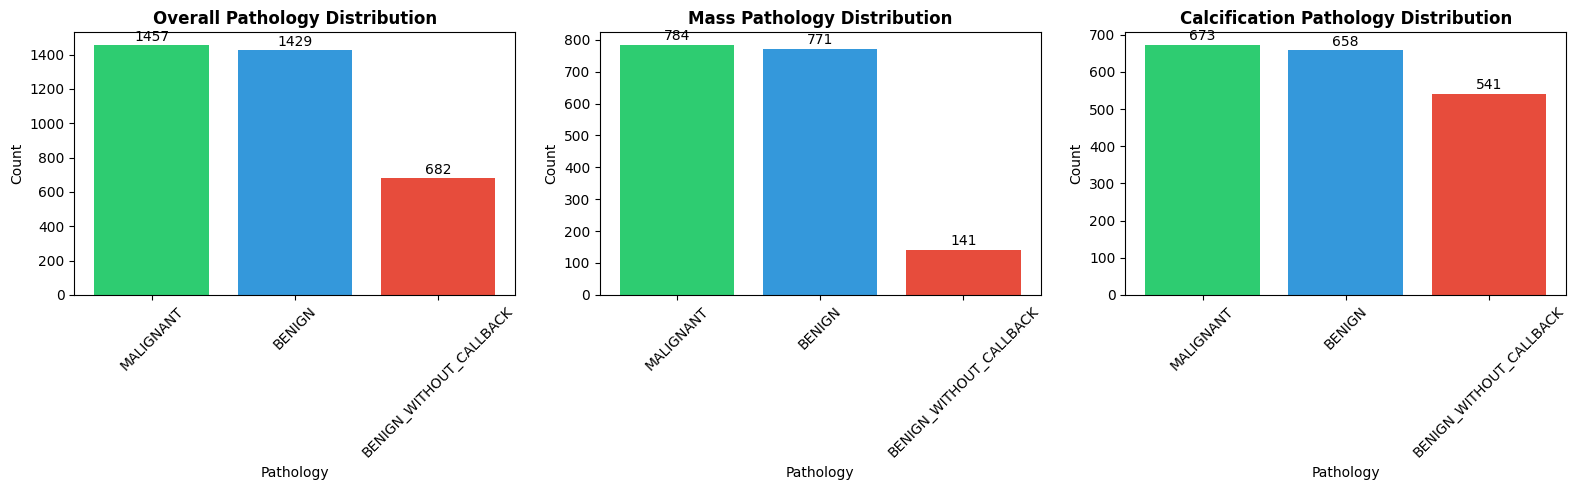

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall pathology distribution
pathology_counts = all_df['pathology'].value_counts()
axes[0].bar(pathology_counts.index, pathology_counts.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Overall Pathology Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pathology')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(pathology_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom')

# Mass pathology distribution
mass_pathology = all_df[all_df['abnormality type'] == "mass"]['pathology'].value_counts()
axes[1].bar(mass_pathology.index, mass_pathology.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Mass Pathology Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pathology')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(mass_pathology.values):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom')

# Calcification pathology distribution
calc_pathology = all_df[all_df['abnormality type'] == "calcification"]['pathology'].value_counts()
axes[2].bar(calc_pathology.index, calc_pathology.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[2].set_title('Calcification Pathology Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Pathology')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(calc_pathology.values):
    axes[2].text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### BI-RADS Assessment Distribution

The BI-RADS assessment category (0-5) indicates the level of suspicion.

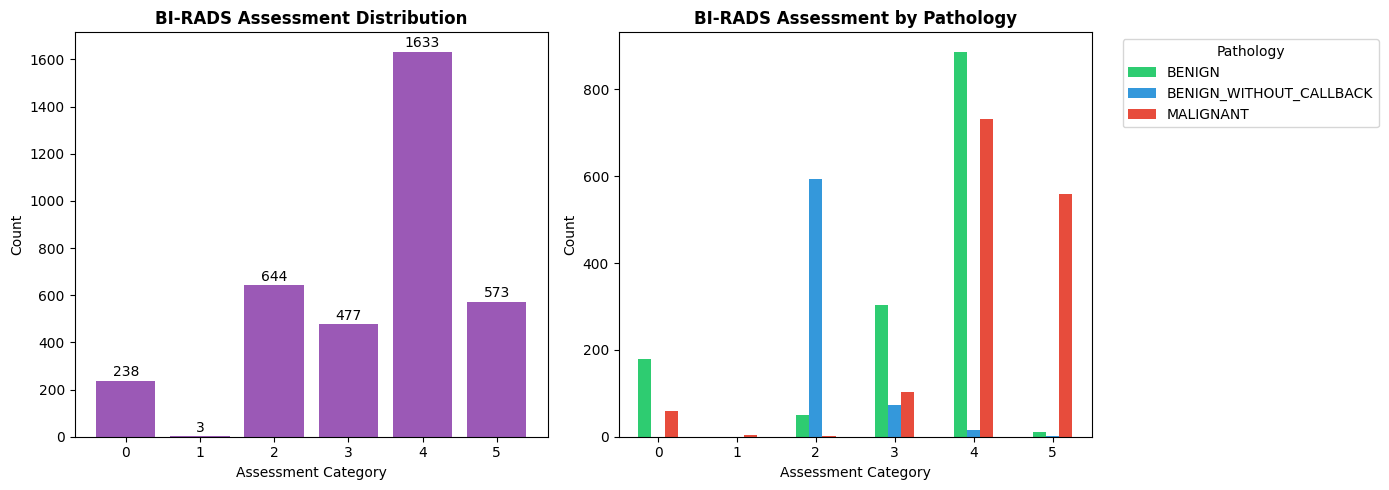

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall assessment distribution
assessment_counts = all_df['assessment'].value_counts().sort_index()
axes[0].bar(assessment_counts.index.astype(str), assessment_counts.values, color='#9b59b6')
axes[0].set_title('BI-RADS Assessment Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Assessment Category')
axes[0].set_ylabel('Count')
for i, (idx, v) in enumerate(assessment_counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom')

# Assessment by pathology
pathology_assessment = pd.crosstab(all_df['assessment'], all_df['pathology'])
pathology_assessment.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('BI-RADS Assessment by Pathology', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Assessment Category')
axes[1].set_ylabel('Count')
axes[1].legend(title='Pathology', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Abnormality Type Distribution

Next we breakdown the abnormality type.

Pie chart source: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html#sphx-glr-gallery-pie-and-polar-charts-pie-features-py

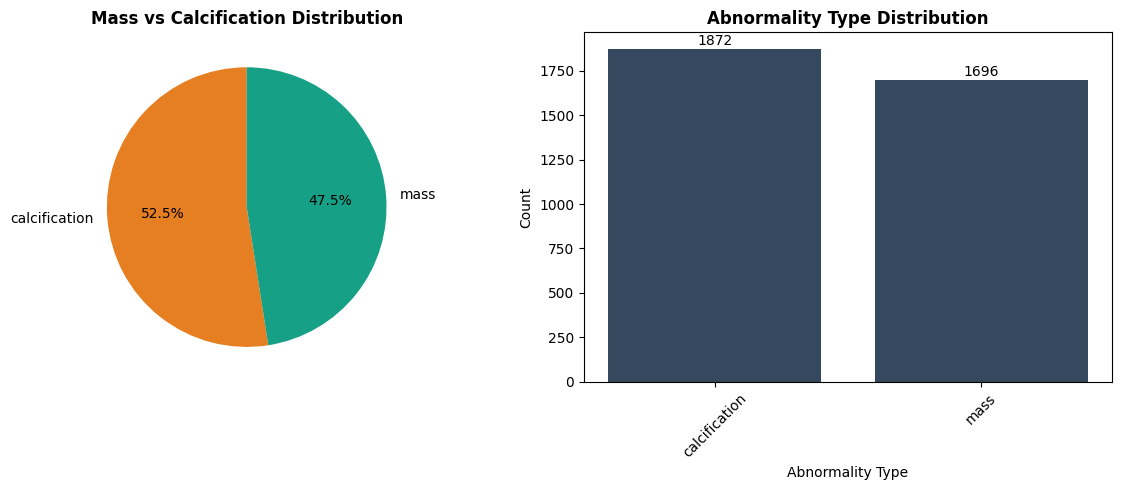

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Abnormality category
abnormality_counts = all_df['abnormality type'].value_counts()
axes[0].pie(abnormality_counts.values, labels=abnormality_counts.index, autopct='%1.1f%%',
            colors=['#e67e22', '#16a085'], startangle=90)
axes[0].set_title('Mass vs Calcification Distribution', fontsize=12, fontweight='bold')

# Abnormality type (from the original column)
abnormality_type_counts = all_df['abnormality type'].value_counts()
axes[1].bar(abnormality_type_counts.index, abnormality_type_counts.values, color='#34495e')
axes[1].set_title('Abnormality Type Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Abnormality Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(abnormality_type_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Shape and Margins Distribution

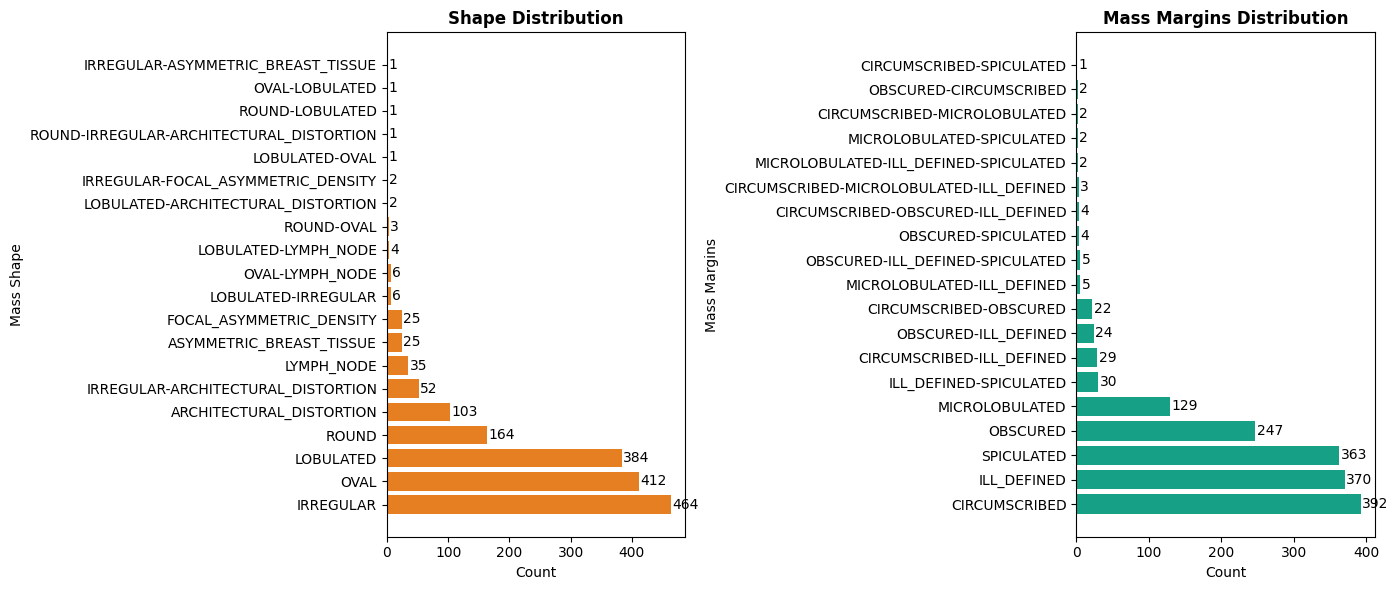

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

shape_counts = all_df['mass shape'].value_counts()
axes[0].barh(shape_counts.index, shape_counts.values, color='#e67e22')
axes[0].set_title('Shape Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Mass Shape')
for i, v in enumerate(shape_counts.values):
    axes[0].text(v + 2, i, str(v), va='center')

# Mass margins
margins_counts = all_df['mass margins'].value_counts()
axes[1].barh(margins_counts.index, margins_counts.values, color='#16a085')
axes[1].set_title('Mass Margins Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Mass Margins')
for i, v in enumerate(margins_counts.values):
    axes[1].text(v + 2, i, str(v), va='center')

plt.tight_layout()
plt.show()

### Breast Density Distribution

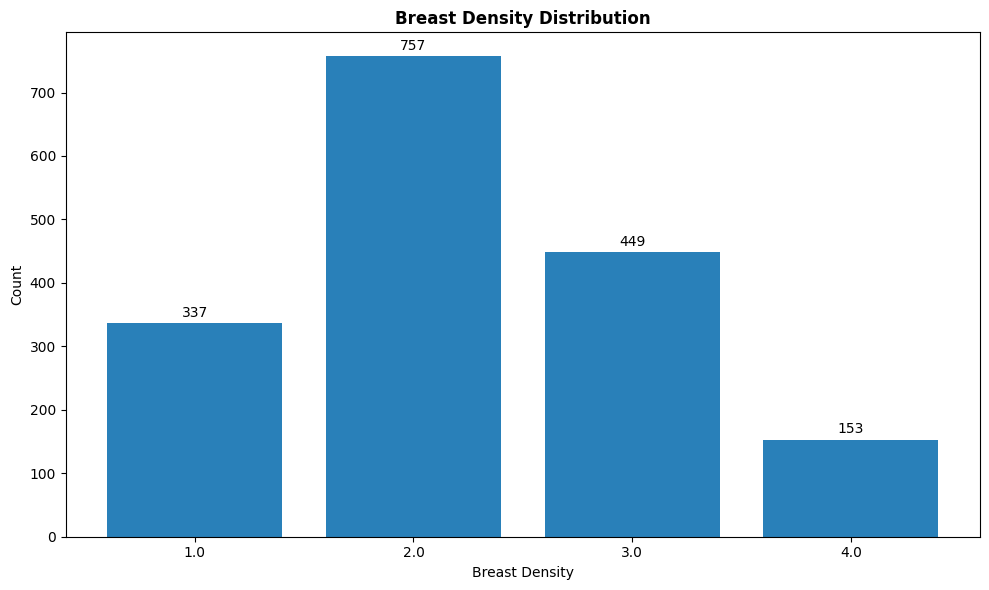

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

# Handle both column name formats
density_col = 'breast_density' if 'breast_density' in all_df.columns else 'breast density'
breast_density_counts = all_df[density_col].value_counts().sort_index()

ax.bar(breast_density_counts.index.astype(str), breast_density_counts.values, color='#2980b9')
ax.set_title('Breast Density Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Breast Density')
ax.set_ylabel('Count')
for i, v in enumerate(breast_density_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Subtlety Distribution

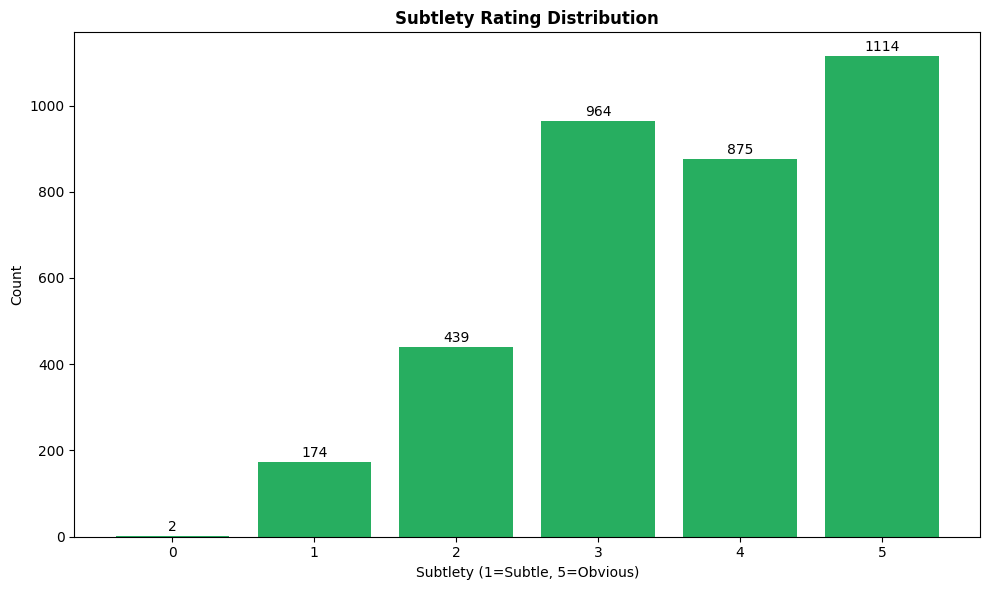

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

subtlety_counts = all_df['subtlety'].value_counts().sort_index()
ax.bar(subtlety_counts.index.astype(str), subtlety_counts.values, color='#27ae60')
ax.set_title('Subtlety Rating Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Subtlety (1=Subtle, 5=Obvious)')
ax.set_ylabel('Count')
for i, v in enumerate(subtlety_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Image Dimensions Analysis

Finally, we analysis the height and width distribution of images across the dataset, to better understand the image sizes in the CBIS-DDSM dataste.

In [48]:
from tqdm import tqdm


def get_image_dimensions(df, desc="Processing"):
    """Extract image dimensions for all images in a dataframe."""
    dimensions = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        try:
            img_path, *_ = get_patient_imgs_from_row(row)
            img = Image.fromarray(dicom_to_array(img_path))
            width, height = img.size
            dimensions.append({
                "patient_id": row["patient_id"],
                "image_view": row["image view"],
                "width": width,
                "height": height,
                "aspect_ratio": width / height
            })
        except Exception as e:
            print(f"Error processing {row['patient_id']}: {e}")
    return pd.DataFrame(dimensions)

In [49]:
dimensions_df = get_image_dimensions(all_df, desc="Analysing image dimensions")

Analysing image dimensions: 100%|█████████████████████████████████████████████████████████████████████████████████████| 3568/3568 [00:57<00:00, 62.35it/s]


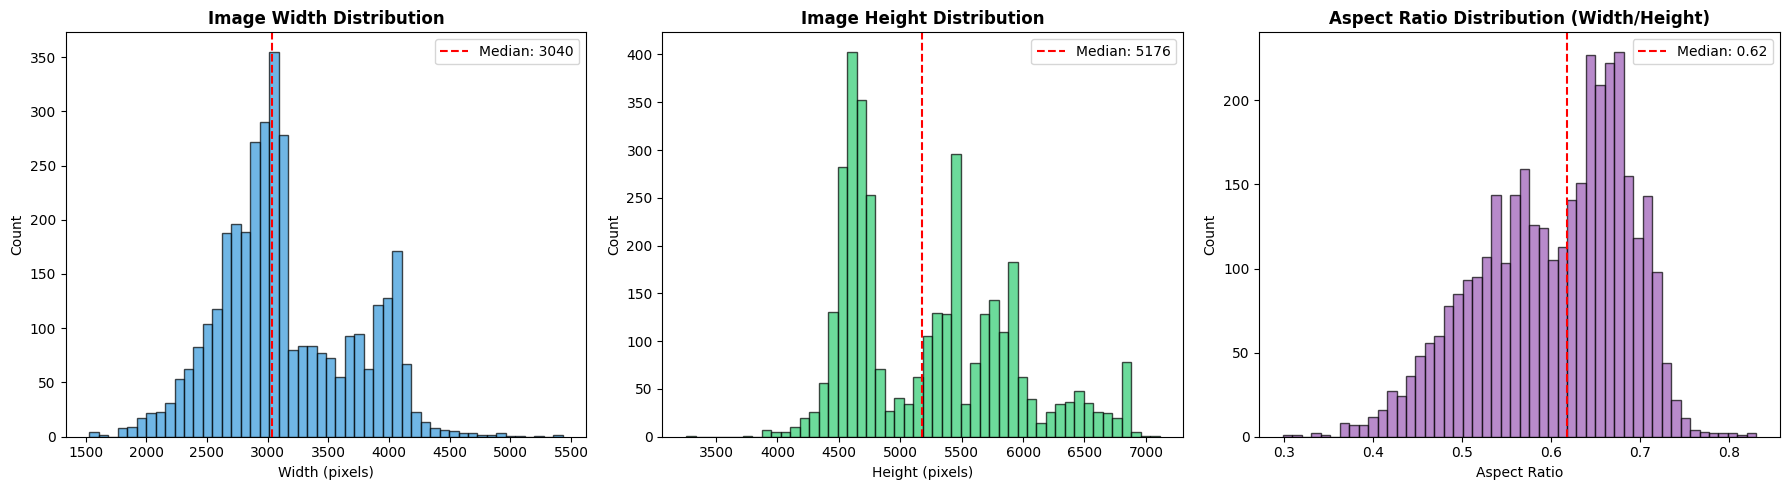

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width distribution
axes[0].hist(dimensions_df['width'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Image Width Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')
axes[0].axvline(dimensions_df['width'].median(), color='red', linestyle='--',
                label=f"Median: {dimensions_df['width'].median():.0f}")
axes[0].legend()

# Height distribution
axes[1].hist(dimensions_df['height'], bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].set_title('Image Height Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')
axes[1].axvline(dimensions_df['height'].median(), color='red', linestyle='--',
                label=f"Median: {dimensions_df['height'].median():.0f}")
axes[1].legend()

# Aspect ratio distribution
axes[2].hist(dimensions_df['aspect_ratio'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[2].set_title('Aspect Ratio Distribution (Width/Height)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Aspect Ratio')
axes[2].set_ylabel('Count')
axes[2].axvline(dimensions_df['aspect_ratio'].median(), color='red', linestyle='--',
                label=f"Median: {dimensions_df['aspect_ratio'].median():.2f}")
axes[2].legend()

plt.tight_layout()
plt.show()